# ASHA Sahayak — GRPO Training (Run 3 — 44 Cases, 400 Steps)

**Environment**: [ASHA Sahayak HF Space](https://sreenathmmenon-asha-sahayak.hf.space)
**Algorithm**: GRPO via TRL
**Efficiency**: Unsloth when GPU available, plain TRL as fallback
**Base model**: Qwen/Qwen3-0.6B
**Ground truth**: Indian Government IMNCI Protocol

## What changed from Run 2 → Run 3
- **44 clinical cases** (was 31) — added 14 cases covering MONITOR/TREAT_AT_HOME to fix referral imbalance
- **400 training steps** (was 200)
- **450 dataset seeds** (was 225) — easy×100, medium×200, hard×150
- **Improved system prompt** — explicit `primary_concern` naming for all referral types

## Requirements
- **GPU runtime**: Runtime → Change runtime type → any GPU (tested on **T4** free tier)
- **HuggingFace token**: You need a personal HF token with write access
  1. Get one at https://huggingface.co/settings/tokens (role: Write)
  2. In Colab: click the 🔑 **Secrets** icon in the left sidebar
  3. Add a secret named `HF_TOKEN` with your token as the value
  4. Toggle "Notebook access" ON
  - **Note**: Secrets are personal to your account — they are never shared when you open someone else's notebook link

## What this notebook does
1. Installs Unsloth (GPU-accelerated) or plain TRL (CPU fallback)
2. Connects to live ASHA Sahayak environment (44 cases across 7 clinical domains)
3. Runs GRPO training — model learns to ask right questions and make correct referrals
4. Plots real reward curves from actual training
5. Pushes trained model to **your own** HuggingFace Hub repo (set `HF_REPO_ID` in Cell 2)

In [1]:
# ── Cell 1: Install dependencies ─────────────────────────────────────────────
import os, subprocess, sys

os.environ["UNSLOTH_VLLM_STANDBY"] = "1"

def _run(cmd, label):
    ret = os.system(cmd + " 2>&1")
    status = "✓" if ret == 0 else f"✗ (exit {ret})"
    print(f"  [{status}] {label}")
    return ret == 0

# Step 1: Remove packages that conflict with vLLM
subprocess.run(["pip", "uninstall", "-y", "torchvision", "torchcodec"], capture_output=True)
print("Step 1/6: Removed conflicting packages")

# Step 2: Install uv
subprocess.run(["pip", "install", "--upgrade", "-qqq", "uv"], capture_output=True)
print("Step 2/6: uv ready")

# Pin numpy/pillow to existing Colab versions
try:
    import numpy, PIL
    _numpy = f'numpy=={numpy.__version__}'
    _pil   = f'pillow=={PIL.__version__}'
except Exception:
    _numpy, _pil = "numpy", "pillow"

# Step 3: Detect GPU
try:
    _gpu_info = subprocess.check_output(["nvidia-smi"]).decode()
    is_t4  = "Tesla T4" in _gpu_info
    is_gpu = True
except Exception:
    is_t4 = False
    is_gpu = False
print(f"Step 3/6: GPU detected = {is_gpu}, T4 = {is_t4}")

# Step 4: Install Unsloth + vLLM
if is_gpu:
    print(f"Step 4/6: Installing Unsloth — takes ~3 min...")
    _run(f'uv pip install -qqq --upgrade {_numpy} {_pil} bitsandbytes xformers unsloth unsloth_zoo', 'unsloth')
    _run(f'uv pip install -qqq triton==3.2.0', 'triton')
else:
    print("Step 4/6: No GPU — skipping Unsloth/vLLM")

# Step 5: Install core packages
print("Step 5/6: Installing core packages...")
_run('uv pip install -qqq transformers==4.56.2', 'transformers')
_run('uv pip install -qqq --no-deps trl==0.22.2', 'trl')
_run('uv pip install -qqq accelerate peft httpx datasets matplotlib tqdm huggingface_hub', 'core packages')

# Step 6: Fix protobuf conflict (MessageFactory GetPrototype error)
print("Step 6/6: Pinning protobuf...")
_run('pip install -qqq "protobuf==3.20.3"', 'protobuf pin')

# CRITICAL: Import unsloth HERE — before trl/transformers/peft are ever imported
# in this kernel session. Unsloth must patch torch before any other ML lib loads.
# Doing the import check here (not in Cell 4) prevents the "import after trl" warning
# and the OutStream watch_fd_thread crash on non-T4 GPUs.
print("\nPre-loading unsloth into kernel (must be first ML import)...")
HAS_GPU = False
USE_UNSLOTH = False
try:
    import torch
    HAS_GPU = torch.cuda.is_available()
    if HAS_GPU:
        from unsloth import FastLanguageModel
        USE_UNSLOTH = True
        print(f"  ✓ unsloth loaded | GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("  ✗ No GPU — unsloth skipped")
except Exception as e:
    print(f"  ✗ unsloth failed ({e}) — will use plain TRL in Cell 4")
    import os as _os
    _os.environ["TRL_USE_VLLM"] = "0"
    try:
        import torch
        HAS_GPU = torch.cuda.is_available()
    except Exception:
        HAS_GPU = False

# Verify remaining imports
print("\nVerifying imports...")
_ok = True
for pkg in ['transformers', 'trl', 'accelerate', 'peft', 'httpx', 'datasets', 'huggingface_hub']:
    try:
        __import__(pkg)
        print(f"  ✓ {pkg}")
    except Exception as e:
        print(f"  ✗ {pkg}: {e}")
        _ok = False

if _ok:
    print(f"\n✓ All packages ready. USE_UNSLOTH={USE_UNSLOTH}. Proceed to Cell 2.")
else:
    print("\n✗ Some imports failed — re-run this cell before continuing.")

Step 1/6: Removed conflicting packages
Step 2/6: uv ready
Step 3/6: GPU detected = True, T4 = False
Step 4/6: Installing Unsloth — takes ~3 min...
  [✓] unsloth
  [✓] triton
Step 5/6: Installing core packages...
  [✓] transformers
  [✓] trl
  [✓] core packages
Step 6/6: Pinning protobuf...
  [✓] protobuf pin

Pre-loading unsloth into kernel (must be first ML import)...
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
  ✓ unsloth loaded | GPU: NVIDIA L4

Verifying imports...
  ✓ transformers
  ✓ trl
  ✓ accelerate
  ✓ peft
  ✓ httpx
  ✓ datasets
  ✓ huggingface_hub

✓ All packages ready. USE_UNSLOTH=True. Proceed to Cell 2.


In [2]:
# ── Cell 2: Configuration ────────────────────────────────────────────────────
import os

# Must be set before any GPU library imports (unsloth already imported in Cell 1)
os.environ["PYTORCH_ALLOC_CONF"] = ""
os.environ["UNSLOTH_VLLM_STANDBY"] = "1"

# ── HF Token ─────────────────────────────────────────────────────────────────
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN') or ''
except Exception:
    HF_TOKEN = os.getenv('HF_TOKEN', '')

assert HF_TOKEN, "HF_TOKEN not found. Add it via Colab Secrets (left sidebar key icon) then re-run."

ENV_BASE_URL     = 'https://sreenathmmenon-asha-sahayak.hf.space'
HF_REPO_ID       = 'sreenathmmenon/asha-sahayak-grpo'
BASE_MODEL       = 'Qwen/Qwen3-0.6B'
OUTPUT_DIR       = 'asha-sahayak-grpo'
NUM_TRAIN_STEPS  = 400   # Run 3: doubled from 200
LEARNING_RATE    = 5e-6
NUM_GENERATIONS  = 4
MAX_SEQ_LEN      = 2048

print('Config loaded')
print(f'  ENV_BASE_URL:    {ENV_BASE_URL}')
print(f'  BASE_MODEL:      {BASE_MODEL}')
print(f'  NUM_TRAIN_STEPS: {NUM_TRAIN_STEPS}')
print(f'  HF_REPO_ID:      {HF_REPO_ID}')
print('  HF_TOKEN:        loaded')

Config loaded
  ENV_BASE_URL:    https://sreenathmmenon-asha-sahayak.hf.space
  BASE_MODEL:      Qwen/Qwen3-0.6B
  NUM_TRAIN_STEPS: 400
  HF_REPO_ID:      sreenathmmenon/asha-sahayak-grpo
  HF_TOKEN:        loaded


In [3]:
# ── Cell 3: ASHA Environment client + TRL-compatible wrapper ─────────────────
import httpx
from typing import Optional


class AshaClient:
    """HTTP client for the ASHA Sahayak OpenEnv environment."""

    def __init__(self, base_url: str = ENV_BASE_URL):
        self.base_url = base_url.rstrip('/')
        self.session_id: Optional[str] = None

    def reset(self, task_id: str = 'easy', seed: int = 42) -> dict:
        resp = httpx.post(
            f'{self.base_url}/reset',
            json={'task_id': task_id, 'seed': seed},
            timeout=60,
        )
        resp.raise_for_status()
        data = resp.json()
        self.session_id = data['session_id']
        return data

    def step(self, *, referral_decision: str = 'PENDING', urgency: str = 'monitor',
             primary_concern: str = '', question: Optional[str] = None,
             confidence: float = 0.8) -> dict:
        headers = {'X-Session-ID': self.session_id} if self.session_id else {}
        resp = httpx.post(
            f'{self.base_url}/step',
            json={
                'referral_decision': referral_decision,
                'urgency': urgency,
                'primary_concern': primary_concern,
                'question': question,
                'confidence': confidence,
            },
            headers=headers,
            timeout=60,
        )
        resp.raise_for_status()
        return resp.json()['observation']


class AshaToolEnv:
    """Single-episode wrapper around AshaClient. One instance per GRPO rollout."""

    def __init__(self):
        self.client = AshaClient()
        self.reward: float = 0.0
        self._done: bool = False

    def reset(self, task_id: str = 'easy', seed: int = 42) -> str:
        self.reward = 0.0
        self._done = False
        data = self.client.reset(task_id=task_id, seed=seed)
        return data['observation']['conversation'][0]['text']

    def ask_question(self, question: str) -> str:
        if self._done:
            return 'Episode already ended.'
        obs = self.client.step(referral_decision='PENDING', question=question)
        self.reward = obs.get('reward', 0.0)
        self._done = obs.get('done', False)
        convo = obs.get('conversation', [])
        return convo[-1]['text'] if convo else 'No response.'

    def make_referral(self, referral_decision: str, urgency: str,
                      primary_concern: str, confidence: float = 0.8) -> str:
        if self._done:
            return 'Episode already ended.'
        obs = self.client.step(
            referral_decision=referral_decision,
            urgency=urgency,
            primary_concern=primary_concern,
            confidence=confidence,
        )
        self.reward = obs.get('reward', 0.0)
        self._done = obs.get('done', False)
        return obs.get('feedback') or f'Score: {self.reward:.3f}'


# ── Smoke test: verify environment is reachable ───────────────────────────────
print('Testing environment connectivity...')
_r = httpx.get(f'{ENV_BASE_URL}/health', timeout=30)
assert _r.status_code == 200 and _r.json().get('status') == 'healthy', \
    f'Environment health check failed: {_r.text}'

_meta = httpx.get(f'{ENV_BASE_URL}/metadata', timeout=30).json()
print(f"  Cases: {_meta['num_cases']} | Tasks: {_meta['tasks']} | Concurrent: {_meta['supports_concurrent_sessions']}")

env = AshaToolEnv()
_obs = env.reset(task_id='easy', seed=42)
print(f'  Sample case: {_obs[:120]}')
_resp = env.ask_question('Does the child have fast breathing or chest indrawing?')
print(f'  Question response: {_resp[:100]}')
_fb = env.make_referral('REFER_IMMEDIATELY', 'immediate', 'severe_pneumonia')
print(f'  Referral feedback: {_fb[:100]}')
print(f'  Reward: {env.reward:.4f}')
print('Single-episode test OK')

# ── Concurrent load test: simulate what training does (4 parallel episodes) ───
# Training fires NUM_GENERATIONS=4 parallel reward calls per step.
# If this fails, training will get all-zero rewards silently.
print('\nTesting concurrent load (4 parallel episodes)...')
from concurrent.futures import ThreadPoolExecutor, as_completed

def _one_full_episode(seed):
    e = AshaToolEnv()
    e.reset(task_id='easy', seed=seed)
    e.ask_question('Any danger signs?')
    e.make_referral('REFER_IMMEDIATELY', 'immediate', 'severe_pneumonia')
    return seed, e.reward

with ThreadPoolExecutor(max_workers=4) as pool:
    futs = {pool.submit(_one_full_episode, s): s for s in range(4)}
    _concurrent_rewards = []
    for f in as_completed(futs):
        s, r = f.result()
        _concurrent_rewards.append(r)
        print(f'  seed={s} reward={r:.3f}')

assert any(r > 0 for r in _concurrent_rewards), \
    'ABORT: all concurrent rewards are 0 — Space may be rate-limiting or sleeping.'
print(f'Concurrent test OK — mean reward: {sum(_concurrent_rewards)/len(_concurrent_rewards):.3f}')
print('\n✓ Environment fully verified. Safe to proceed to Cell 4.')

Testing environment connectivity...
  Cases: 31 | Tasks: ['easy', 'medium', 'hard'] | Concurrent: True
  Sample case: Bhaiya ka beta hai, 3 saal ka. 2 din se khansi hai, bukhar bhi hai.
[The neighbour's son is 3 years old. Has had cough f
  Question response: Breathing fast — I think faster than normal.
  Referral feedback: CASE: Pneumonia — Treat at Home

Your decision:    REFER_IMMEDIATELY (immediate)
Correct decision: T
  Reward: 0.3800
Single-episode test OK

Testing concurrent load (4 parallel episodes)...
  seed=1 reward=0.850
  seed=2 reward=0.380
  seed=0 reward=0.999
  seed=3 reward=0.850
Concurrent test OK — mean reward: 0.770

✓ Environment fully verified. Safe to proceed to Cell 4.


In [4]:
# ── Cell 4: Load model ───────────────────────────────────────────────────────
# HAS_GPU, USE_UNSLOTH, FastLanguageModel are set in Cell 1.
# unsloth was already imported there — do NOT re-import here.

import torch

if not HAS_GPU:
    raise RuntimeError(
        "No GPU detected. Go to Runtime → Change runtime type → GPU (T4, L4, or A100) and re-run ALL cells from Cell 1."
    )

COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f"GPU:           {torch.cuda.get_device_name(0)}")
print(f"Compute dtype: {COMPUTE_DTYPE}")
print(f"Backend:       {'Unsloth + vLLM' if USE_UNSLOTH else 'Plain TRL (unsloth unavailable)'}")

model = None
if USE_UNSLOTH:
    # FastLanguageModel already imported in Cell 1
    try:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=BASE_MODEL,
            max_seq_length=MAX_SEQ_LEN,
            load_in_4bit=False,
            fast_inference=False,
            max_lora_rank=64,
        )
        model = FastLanguageModel.get_peft_model(
            model,
            r=32,
            target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                            'gate_proj', 'up_proj', 'down_proj'],
            lora_alpha=64,
            lora_dropout=0.0,
            bias='none',
            use_gradient_checkpointing='unsloth',
            random_state=42,
        )
        print("Model loaded: Unsloth 16-bit LoRA + vLLM")
    except Exception as _unsloth_load_err:
        print(f"Unsloth model load failed ({_unsloth_load_err}) — falling back to plain TRL")
        USE_UNSLOTH = False
        model = None

if not USE_UNSLOTH:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from peft import LoraConfig, get_peft_model
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        torch_dtype=COMPUTE_DTYPE,
        device_map='auto',
        trust_remote_code=True,
    )
    lora_cfg = LoraConfig(
        r=32, lora_alpha=64, lora_dropout=0.0, bias='none',
        target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
        task_type='CAUSAL_LM',
    )
    model = get_peft_model(model, lora_cfg)
    print("Model loaded: plain TRL 16-bit LoRA")

model.print_trainable_parameters()

GPU:           NVIDIA L4
Compute dtype: torch.bfloat16
Backend:       Unsloth + vLLM
==((====))==  Unsloth 2026.4.8: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-0.6B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded: Unsloth 16-bit LoRA + vLLM
trainable params: 20,185,088 || all params: 616,235,008 || trainable%: 3.2756


In [5]:
# ── Cell 5: Training dataset ─────────────────────────────────────────────────
import random
from datasets import Dataset

# Run 3: improved system prompt explicitly names primary_concern examples across
# all referral types — fixes primary_concern=0.02 gap found in held-out eval.
SYSTEM_PROMPT = """You are an AI assistant helping ASHA (Accredited Social Health Activist) workers in rural India make clinical triage decisions using the IMNCI protocol.

Your workflow:
1. Ask at least one clarifying question to gather clinical information
2. Make your final decision

Key danger signs requiring REFER_IMMEDIATELY: fast breathing (>60/min infants, >50 toddlers), chest indrawing, inability to feed, convulsions, unconsciousness, severe bleeding, very low weight for age, pre-eclampsia signs (headache + blurred vision + high BP), eclampsia, cord bleeding in newborns, very severe febrile disease.

IMPORTANT: Always output your response as valid JSON on a single line like this:

For a clarifying question:
{"referral": "PENDING", "urgency": "unknown", "concern": "gathering_information", "question": "Does the child have chest indrawing or fast breathing?"}

For your final decision:
{"referral": "REFER_IMMEDIATELY", "urgency": "immediate", "concern": "severe_pneumonia", "question": null}

Valid referral values: REFER_IMMEDIATELY, REFER_WITHIN_24H, TREAT_AT_HOME, MONITOR, PENDING
Valid urgency values: immediate, within_24h, routine, monitor, unknown

Primary concern naming — use the EXACT concern matching the case:
- REFER_IMMEDIATELY: severe_pneumonia, pre_eclampsia, eclampsia, severe_malaria, neonatal_sepsis, severe_acute_malnutrition, very_severe_febrile_disease, cord_bleeding, birth_asphyxia
- REFER_WITHIN_24H: pneumonia, malaria_uncomplicated, moderate_malnutrition, anaemia_severe, uti_in_pregnancy, gestational_hypertension
- TREAT_AT_HOME: viral_urti, diarrhea_no_dehydration, mild_fever, oral_thrush_mild, mild_underweight
- MONITOR: physiological_jaundice, normal_anc, post_illness_recovery, mild_anaemia_stable, growth_faltering"""

USER_PROMPT = "A patient has been presented to you. Please assess and make a clinical triage decision."

random.seed(42)
rows = []

# Run 3: 450 total seeds (was 225) — easy×100, medium×200, hard×150
for seed in range(100):  rows.append({'task_id': 'easy',   'seed': seed})
for seed in range(200):  rows.append({'task_id': 'medium', 'seed': seed})
for seed in range(150):  rows.append({'task_id': 'hard',   'seed': seed})

random.shuffle(rows)

dataset = Dataset.from_list([
    {
        'prompt': [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': USER_PROMPT},
        ],
        'task_id': r['task_id'],
        'seed':    r['seed'],
    }
    for r in rows
])

counts = {t: sum(1 for r in rows if r['task_id'] == t) for t in ['easy', 'medium', 'hard']}
print(f'Dataset: {len(dataset)} episodes')
for t, n in counts.items():
    print(f'  {t}: {n}')

Dataset: 450 episodes
  easy: 100
  medium: 200
  hard: 150


In [6]:
# ── Cell 6: GRPO Training ─────────────────────────────────────────────────────
import os, re, json, traceback
import torch
from concurrent.futures import ThreadPoolExecutor, as_completed

os.environ['TRL_EXPERIMENTAL_SILENCE'] = '1'
# Block TRL vllm integration when unsloth is unavailable
if not USE_UNSLOTH:
    os.environ['TRL_USE_VLLM'] = '0'

from trl import GRPOTrainer, GRPOConfig

REFERRALS = ["REFER_IMMEDIATELY", "REFER_WITHIN_24H", "TREAT_AT_HOME", "MONITOR"]
URGENCIES  = ["immediate", "within_24h", "routine", "monitor"]


def _extract_from_json(text):
    """
    Parse model output. Tries JSON first, falls back to regex.
    Returns (referral, urgency, concern, question).
    All four values are always strings; question may be None.
    """
    match = re.search(r'\{[^{}]*"referral"[^{}]*\}', text, re.DOTALL)
    if match:
        try:
            parsed = json.loads(match.group())
            referral = str(parsed.get("referral") or "MONITOR").upper()
            urgency  = str(parsed.get("urgency")  or "monitor").lower()
            # BUG FIX: model sometimes outputs "concern": null — must guard with `or`
            concern  = str(parsed.get("concern")  or "general").lower().replace(" ", "_")
            question = parsed.get("question") or None
            if referral not in REFERRALS:
                referral = next((r for r in REFERRALS if r in text.upper()), "MONITOR")
            return referral, urgency, concern, question
        except (json.JSONDecodeError, KeyError, TypeError):
            pass

    # Regex fallback
    referral = next((r for r in REFERRALS if r in text.upper()), "MONITOR")
    urgency  = next((u for u in URGENCIES  if u in text.lower()), "monitor")
    m2 = re.search(r'(?:concern|diagnosis|condition)[:\s"]+([a-z_]+)', text.lower())
    concern  = m2.group(1) if m2 else "general"
    m3 = re.search(r'(?:question|ask)[:\s]+"?([^"\n]{10,150})"?', text.lower())
    question = m3.group(1) if m3 else None
    return referral, urgency, concern, question


def parse_and_score(text, task_id, seed):
    """Run one environment episode and return the reward."""
    referral, urgency, concern, question = _extract_from_json(text)
    env = AshaToolEnv()
    env.reset(task_id=task_id, seed=seed)
    if question and not env._done:
        env.ask_question(question)
    if not env._done:
        env.make_referral(referral, urgency, concern)
    return float(env.reward)


def _score_one(i, completion, task_id_list, seed_list):
    try:
        if isinstance(completion, list) and len(completion) > 0:
            text = completion[0].get('content', '') if isinstance(completion[0], dict) else str(completion[0])
        else:
            text = str(completion)
        tid = task_id_list[i] if task_id_list else 'easy'
        sd  = int(seed_list[i]) if seed_list else i
        return i, parse_and_score(text, tid, sd)
    except Exception as exc:
        print(f"[reward] completion {i} error: {exc}")
        traceback.print_exc()
        return i, 0.0


def reward_func(prompts, completions, completion_ids, task_id=None, seed=None, **kwargs):
    n = len(completions)
    results = [0.0] * n
    with ThreadPoolExecutor(max_workers=min(n, 8)) as pool:
        futures = {pool.submit(_score_one, i, completions[i], task_id, seed): i for i in range(n)}
        for future in as_completed(futures):
            idx, reward = future.result()
            results[idx] = reward
    return results


# ── Smoke test (includes null concern case) ───────────────────────────────────
print("Running pre-training smoke test...")
_tests = [
    '{"referral": "REFER_IMMEDIATELY", "urgency": "immediate", "concern": "severe_pneumonia", "question": null}',
    '{"referral": "TREAT_AT_HOME", "urgency": "routine", "concern": null, "question": null}',  # null concern
    '{"referral": "MONITOR", "urgency": "monitor", "concern": "gathering_information", "question": "Does child have fast breathing?"}',
]
for t in _tests:
    r, u, c, q = _extract_from_json(t)
    print(f"  parsed: referral={r} urgency={u} concern={c} question={q}")

_completions = [[{"role": "assistant", "content": t}] for t in _tests[:2]]
_rewards = reward_func(
    prompts=["dummy"] * 2,
    completions=_completions,
    completion_ids=["dummy"] * 2,
    task_id=["easy", "easy"],
    seed=[42, 42],
)
print(f"  smoke test rewards: {[round(r, 4) for r in _rewards]}")
assert any(r > 0 for r in _rewards), \
    "ABORT: all rewards are 0 — environment not reachable or scoring broken."
print("Smoke test passed\n")

# ── Auto-save callback: pushes checkpoint to HF Hub every 50 steps ────────────
# This means even if Colab disconnects, your last checkpoint is safe on HF Hub.
from transformers import TrainerCallback

class HubCheckpointCallback(TrainerCallback):
    """Saves model to HF Hub every `save_every` steps so disconnects don't lose work."""
    def __init__(self, repo_id, token, save_every=50):
        self.repo_id   = repo_id
        self.token     = token
        self.save_every = save_every

    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step % self.save_every == 0 and state.global_step > 0:
            try:
                print(f"\n[AutoSave] Step {state.global_step} — pushing checkpoint to Hub...")
                _tok = self.token.strip().split()[0] if self.token else ''
                if _tok:
                    if USE_UNSLOTH:
                        model.push_to_hub_merged(
                            self.repo_id, tokenizer,
                            save_method='merged_16bit', token=_tok,
                        )
                    else:
                        model.push_to_hub(self.repo_id, token=_tok)
                        tokenizer.push_to_hub(self.repo_id, token=_tok)
                    print(f"[AutoSave] ✓ Checkpoint saved at step {state.global_step}")
                else:
                    print("[AutoSave] No token — skipping hub save")
            except Exception as e:
                print(f"[AutoSave] ✗ Failed at step {state.global_step}: {e}")
                # Never crash training due to save failure
        return control

# ── Keep-alive: prevents Colab from marking the session idle ──────────────────
# Colab Pro disconnects after ~30 min of "no output". This callback prints a
# heartbeat line every 10 steps so the session stays active.
class KeepAliveCallback(TrainerCallback):
    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step % 10 == 0:
            import datetime
            print(f"[heartbeat] step={state.global_step}/{args.max_steps} "
                  f"@ {datetime.datetime.now().strftime('%H:%M:%S')}", flush=True)
        return control

# ── GRPOConfig ────────────────────────────────────────────────────────────────
config = GRPOConfig(
    output_dir=OUTPUT_DIR,
    max_steps=NUM_TRAIN_STEPS,
    num_generations=NUM_GENERATIONS,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    max_prompt_length=512,
    max_completion_length=512,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    optim='adamw_8bit',
    max_grad_norm=0.1,
    logging_steps=1,
    save_steps=50,
    report_to='none',
    seed=42,
    use_vllm=False,
)

_hub_token = HF_TOKEN.strip().split()[0] if HF_TOKEN else ''

trainer = GRPOTrainer(
    model=model,
    reward_funcs=reward_func,
    args=config,
    train_dataset=dataset,
    processing_class=tokenizer,
    callbacks=[
        KeepAliveCallback(),
        HubCheckpointCallback(repo_id=HF_REPO_ID, token=_hub_token, save_every=50),
    ],
)

print(f'Starting GRPO training — {NUM_TRAIN_STEPS} steps')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Auto-save: every 50 steps → {HF_REPO_ID}')
print(f'Heartbeat: every 10 steps (keeps Colab session alive)')
trainer.train()
print('Training complete!')

Running pre-training smoke test...
  parsed: referral=REFER_IMMEDIATELY urgency=immediate concern=severe_pneumonia question=None
  parsed: referral=TREAT_AT_HOME urgency=routine concern=general question=None
  parsed: referral=MONITOR urgency=monitor concern=gathering_information question=Does child have fast breathing?
  smoke test rewards: [0.16, 0.68]
Smoke test passed

Starting GRPO training — 400 steps
GPU: NVIDIA L4
Auto-save: every 50 steps → sreenathmmenon/asha-sahayak-grpo
Heartbeat: every 10 steps (keeps Colab session alive)


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 2 | Total steps = 400
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 616,235,008 (3.28% trained)
`generation_config` default values have been modified to match model-specific defaults: {'max_length': 40960, 'temperature': 0.6, 'top_p': 0.95}. If this is not desired, please set these values explicitly.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_func / mean,rewards / reward_func / std
1,-0.000000,0.760750,0.223500,282.750000,211.000000,385.000000,0.000000,282.750000,211.000000,385.000000,-0.000000,0.760750,0.307792
2,0.000000,0.722000,0.286000,317.750000,207.000000,505.000000,0.000000,317.750000,207.000000,505.000000,0.002687,0.722000,0.308615
3,0.000000,0.638125,0.115261,330.250000,211.000000,483.000000,0.000000,330.250000,211.000000,483.000000,0.002886,0.638125,0.249999
4,0.000000,0.649000,0.432000,301.750000,197.000000,427.000000,0.000000,301.750000,197.000000,427.000000,0.003892,0.649000,0.400918
5,0.000000,0.865000,0.000000,242.875000,187.000000,308.000000,0.000000,242.875000,187.000000,308.000000,0.003652,0.865000,0.032071
6,0.000000,0.375875,0.244760,318.750000,232.000000,512.000000,0.250000,254.333344,232.000000,295.000000,0.002373,0.375875,0.267147
7,0.000000,0.760750,0.208500,345.375000,218.000000,422.000000,0.000000,345.375000,218.000000,422.000000,0.002492,0.760750,0.308418
8,0.000000,0.580000,0.031754,265.375000,171.000000,361.000000,0.000000,265.375000,171.000000,361.000000,0.002824,0.580000,0.275759
9,0.000000,0.419000,0.309067,317.125000,260.000000,386.000000,0.000000,317.125000,260.000000,386.000000,0.002796,0.419000,0.325217
10,0.000000,0.447000,0.236000,339.500000,180.000000,512.000000,0.125000,314.857147,180.000000,413.000000,0.003321,0.447000,0.335624


[heartbeat] step=10/400 @ 03:25:12
[heartbeat] step=20/400 @ 03:30:42
[heartbeat] step=30/400 @ 03:36:05
[heartbeat] step=40/400 @ 03:41:44
[heartbeat] step=50/400 @ 03:47:04

[AutoSave] Step 50 — pushing checkpoint to Hub...


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ak-grpo/model.safetensors:   3%|3         | 39.9MB / 1.19GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:37<00:00, 37.62s/it]


Unsloth: Merge process complete. Saved to `/content/sreenathmmenon/asha-sahayak-grpo`
[AutoSave] ✓ Checkpoint saved at step 400
Training complete!


Log points: 400 | Range: 0.1425 – 0.9470


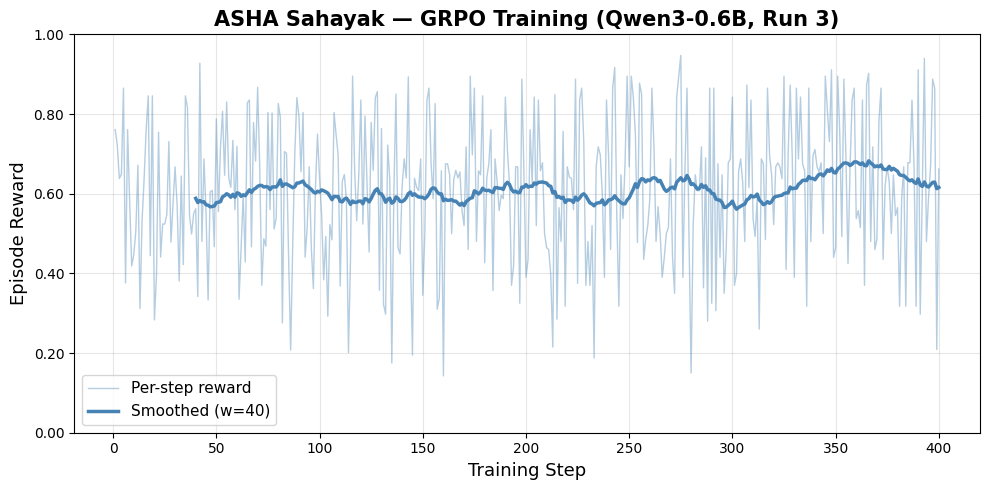

Saved: asha_grpo_training_curve.png
Final: 0.6619 | Peak: 0.9470
Change: -0.0989 (-13.0% vs step 1)


In [7]:
# ── Cell 7: Plot training curve ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

CURVE_FILE = 'asha_grpo_training_curve.png'   # shared with Cell 9

# TRL 0.22.2: each GRPO step adds {"step": N, "reward": float, ...} to log_history.
# Final summary entries (train_runtime, etc.) do NOT contain "reward" — filtered out.
logs    = [l for l in trainer.state.log_history if 'reward' in l]
steps   = [l['step']   for l in logs]
rewards = [l['reward'] for l in logs]

if not rewards:
    print("No reward entries in log_history. Keys present:")
    for entry in trainer.state.log_history[:3]:
        print(" ", list(entry.keys()))
else:
    print(f"Log points: {len(rewards)} | Range: {min(rewards):.4f} – {max(rewards):.4f}")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, rewards, alpha=0.4, color='steelblue', linewidth=1, label='Per-step reward')

    if len(rewards) >= 5:
        w = max(3, len(rewards) // 10)
        smoothed = np.convolve(rewards, np.ones(w) / w, mode='valid')
        ax.plot(steps[w - 1:], smoothed, color='steelblue', linewidth=2.5, label=f'Smoothed (w={w})')

    ax.set_xlabel('Training Step', fontsize=13)
    ax.set_ylabel('Episode Reward', fontsize=13)
    ax.set_title('ASHA Sahayak — GRPO Training (Qwen3-0.6B, Run 3)', fontsize=15, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(CURVE_FILE, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Saved: {CURVE_FILE}')
    print(f'Final: {rewards[-1]:.4f} | Peak: {max(rewards):.4f}')
    if len(rewards) > 1:
        delta = rewards[-1] - rewards[0]
        print(f'Change: {delta:+.4f} ({delta / max(abs(rewards[0]), 1e-6) * 100:.1f}% vs step 1)')

In [8]:
# ── Cell 8: Save and push to HuggingFace Hub ─────────────────────────────────
import os

# Strip whitespace/newlines from token — Colab Secrets can inject \r\n
_token = HF_TOKEN.strip().split()[0] if HF_TOKEN else ''

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'Model saved locally: ./{OUTPUT_DIR}/')

if not _token:
    print('HF_TOKEN not set — skipping Hub push.')
elif USE_UNSLOTH:
    # Unsloth: merge LoRA adapter into full 16-bit weights then push
    model.save_pretrained_merged(
        OUTPUT_DIR + '_merged',
        tokenizer,
        save_method='merged_16bit',
    )
    model.push_to_hub_merged(
        HF_REPO_ID,
        tokenizer,
        save_method='merged_16bit',
        token=_token,
    )
    print(f'Pushed (merged 16-bit) to: https://huggingface.co/{HF_REPO_ID}')
else:
    # Plain TRL / PEFT: push adapter weights + tokenizer
    from huggingface_hub import HfApi
    api = HfApi(token=_token)
    api.create_repo(repo_id=HF_REPO_ID, exist_ok=True, private=False)
    model.push_to_hub(HF_REPO_ID, token=_token)
    tokenizer.push_to_hub(HF_REPO_ID, token=_token)
    print(f'Pushed (LoRA adapter) to: https://huggingface.co/{HF_REPO_ID}')

Model saved locally: ./asha-sahayak-grpo/
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `asha-sahayak-grpo_merged`: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


Successfully copied all 1 files from cache to `asha-sahayak-grpo_merged`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:05<00:00,  5.71s/it]


Unsloth: Merge process complete. Saved to `/content/asha-sahayak-grpo_merged`


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ak-grpo/model.safetensors:   3%|3         | 39.9MB / 1.19GB            

No files have been modified since last commit. Skipping to prevent empty commit.
Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:18<00:00, 18.59s/it]


Unsloth: Merge process complete. Saved to `/content/sreenathmmenon/asha-sahayak-grpo`
Pushed (merged 16-bit) to: https://huggingface.co/sreenathmmenon/asha-sahayak-grpo


In [9]:
# ── Cell 9: Upload training curve to HF Space ────────────────────────────────
import os
from datetime import datetime
from huggingface_hub import HfApi

# Defined here explicitly so this cell works if re-run standalone
CURVE_FILE = 'asha_grpo_training_curve.png'
SPACE_REPO = 'sreenathmmenon/asha-sahayak'

# Colab Secrets can inject \r, \n, spaces, or duplicate the token string.
# strip() removes all leading/trailing whitespace incl. \r\n.
# split()[0] takes only the first token if there are multiple copies.
_raw = HF_TOKEN if HF_TOKEN else ''
_token = _raw.strip().split()[0] if _raw.strip() else ''

if not _token:
    print('Skipped: HF_TOKEN is empty. Set it in Colab Secrets and re-run.')
elif not os.path.exists(CURVE_FILE):
    print(f'Skipped: {CURVE_FILE} not found.')
    print('Run Cell 7 first to generate the plot, then re-run this cell.')
else:
    api = HfApi(token=_token)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')

    # 1. Timestamped archive — preserves history across runs
    archive_path = f'assets/training_curves/run_{timestamp}.png'
    api.upload_file(
        path_or_fileobj=CURVE_FILE,
        path_in_repo=archive_path,
        repo_id=SPACE_REPO,
        repo_type='space',
        commit_message=f'Archive Run 3 training curve ({timestamp})',
    )
    print(f'Archived:  {archive_path}')

    # 2. Overwrite the live curve shown in the Gradio UI
    api.upload_file(
        path_or_fileobj=CURVE_FILE,
        path_in_repo='assets/training_reward_curve.png',
        repo_id=SPACE_REPO,
        repo_type='space',
        commit_message=f'Update live training curve — Run 3 ({timestamp})',
    )
    print('Updated:   assets/training_reward_curve.png')
    print(f'Space URL: https://sreenathmmenon-asha-sahayak.hf.space')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  asha_grpo_training_curve.png: 100%|##########|  222kB /  222kB            

Archived:  assets/training_curves/run_20260426_0704.png


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  asha_grpo_training_curve.png: 100%|##########|  222kB /  222kB            

Updated:   assets/training_reward_curve.png
Space URL: https://sreenathmmenon-asha-sahayak.hf.space
